# HDR Processing Notebook

## Part 1: Inspecting the `.dng` Files

Before applying HDR processing, we first need to understand what kind of data is stored inside the `.dng` files.

This is especially important for smartphone RAW files. For example, Samsung Expert RAW may save computational RAW or Linear DNG files rather than conventional Bayer RAW files. These files may not behave like standard camera RAW files and may not be readable by all tools.

In this section, we check whether the `.dng` files can be read by:

1. `rawpy`, which is commonly used for conventional RAW files.
2. `OpenCV`, which can read common image formats but usually cannot decode RAW sensor data.
3. `tifffile`, which can inspect TIFF/DNG containers and reveal internal metadata.

Based on this diagnosis, we will decide how to load the images for the HDR pipeline.

# Cell 1: Imports

In [1]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cell 2: Define image paths


In [2]:
image_dir = Path("images")

low_exposure_path = image_dir / "low_exposure.dng"
mid_exposure_path = image_dir / "mid_exposure.dng"
high_exposure_path = image_dir / "high_exposure.dng"

dng_paths = [
    low_exposure_path,
    mid_exposure_path,
    high_exposure_path,
]

for path in dng_paths:
    print(path)

images/low_exposure.dng
images/mid_exposure.dng
images/high_exposure.dng


# Cell 3: Basic file checks


In [3]:

def inspect_file_basic(path):
    path = Path(path)

    print(f"File: {path}")
    print(f"Exists: {path.exists()}")

    if path.exists():
        size_mb = path.stat().st_size / (1024 * 1024)
        print(f"Size: {size_mb:.2f} MB")

    print("-" * 60)


for path in dng_paths:
    inspect_file_basic(path)

File: images/low_exposure.dng
Exists: True
Size: 26.22 MB
------------------------------------------------------------
File: images/mid_exposure.dng
Exists: True
Size: 30.08 MB
------------------------------------------------------------
File: images/high_exposure.dng
Exists: True
Size: 30.03 MB
------------------------------------------------------------


## 1.1 Try Reading the DNG Files with rawpy

`rawpy` is a Python wrapper around LibRaw. It is commonly used to read conventional camera RAW files.

If `rawpy` can read the file, then the `.dng` likely contains conventional RAW data that can be decoded into an RGB image.

If it fails, the file may be unsupported, non-standard, computational RAW, or Linear DNG.

# Cell 4: Try reading with rawpy


In [4]:

def test_rawpy_read(path):
    path = Path(path)

    print(f"Testing rawpy on: {path.name}")

    try:
        import rawpy

        with rawpy.imread(str(path)) as raw:
            print("rawpy read: SUCCESS")
            print("raw type:", type(raw))

            try:
                print("raw image shape:", raw.raw_image.shape)
                print("raw image dtype:", raw.raw_image.dtype)
                print("raw image min/max:", raw.raw_image.min(), raw.raw_image.max())
            except Exception as exc:
                print("Could not inspect raw.raw_image:", exc)

            try:
                rgb = raw.postprocess(
                    use_camera_wb=True,
                    no_auto_bright=True,
                    output_bps=16
                )

                print("postprocessed RGB shape:", rgb.shape)
                print("postprocessed RGB dtype:", rgb.dtype)
                print("postprocessed RGB min/max:", rgb.min(), rgb.max())

            except Exception as exc:
                print("rawpy postprocess failed:", exc)

    except ImportError:
        print("rawpy is not installed.")
        print("Install with: pip install rawpy")

    except Exception as exc:
        print("rawpy read: FAILED")
        print("Error type:", type(exc).__name__)
        print("Error message:", exc)

    print("-" * 60)


for path in dng_paths:
    test_rawpy_read(path)

Testing rawpy on: low_exposure.dng
rawpy read: SUCCESS
raw type: <class 'rawpy._rawpy.RawPy'>
raw image shape: (3060, 4080, 4)
raw image dtype: uint16
raw image min/max: 0 3373
postprocessed RGB shape: (4080, 3060, 3)
postprocessed RGB dtype: uint16
postprocessed RGB min/max: 0 65535
------------------------------------------------------------
Testing rawpy on: mid_exposure.dng
rawpy read: SUCCESS
raw type: <class 'rawpy._rawpy.RawPy'>


images/mid_exposure.dng: data corrupted at 14460401


Could not inspect raw.raw_image: Data error or unsupported file format
rawpy postprocess failed: b'Out of order call of libraw function'
------------------------------------------------------------
Testing rawpy on: high_exposure.dng
rawpy read: SUCCESS
raw type: <class 'rawpy._rawpy.RawPy'>


images/high_exposure.dng: data corrupted at 4415585


Could not inspect raw.raw_image: Data error or unsupported file format
rawpy postprocess failed: b'Out of order call of libraw function'
------------------------------------------------------------


## 1.2 Try Reading the DNG Files with OpenCV

OpenCV can read many image formats such as JPEG, PNG, and TIFF. However, it usually cannot decode RAW sensor mosaic data.

If OpenCV reads the file successfully, then the `.dng` is probably already stored in an image-like format that OpenCV understands.

If OpenCV fails with messages related to `PhotometricInterpretation`, this usually means the file is a DNG/TIFF container with image data encoded in a way OpenCV cannot directly interpret.

# Cell 5: Try reading with OpenCV


In [5]:

def test_opencv_read(path):
    path = Path(path)

    print(f"Testing OpenCV on: {path.name}")

    img = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)

    if img is None:
        print("OpenCV read: FAILED")
        print("cv2.imread returned None")

    else:
        print("OpenCV read: SUCCESS")
        print("shape:", img.shape)
        print("dtype:", img.dtype)
        print("min/max:", img.min(), img.max())

        if img.ndim == 2:
            print("channels: 1 grayscale/single-channel")
        elif img.ndim == 3:
            print("channels:", img.shape[-1])

    print("-" * 60)


for path in dng_paths:
    test_opencv_read(path)

Testing OpenCV on: low_exposure.dng
OpenCV read: FAILED
cv2.imread returned None
------------------------------------------------------------
Testing OpenCV on: mid_exposure.dng
OpenCV read: FAILED
cv2.imread returned None
------------------------------------------------------------
Testing OpenCV on: high_exposure.dng
OpenCV read: FAILED
cv2.imread returned None
------------------------------------------------------------


[ WARN:0@8.230] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 37398 (0x9216) encountered
[ WARN:0@8.230] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 50964 (0xc714) encountered
[ WARN:0@8.231] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 50965 (0xc715) encountered
[ WARN:0@8.231] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 51009 (0xc741) encountered
[ WARN:0@8.231] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 51041 (0xc761) encountered
[ WARN:0@8.234] global grfmt_tiff.cpp:804 readData OpenCV TIFF: TIFFRGBAImageOK: Sorry, can not handle images with 12-bit samples
[ WARN:0@8.241] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 37398 (0x9216) encountered
[ WARN:0@8.241] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 50964 (0xc714) encountered
[ 

## 1.3 Inspect the DNG/TIFF Structure with tifffile

DNG is based on the TIFF container format. Even when OpenCV or rawpy cannot fully read the file, `tifffile` can often inspect the internal pages, tags, shapes, data types, and photometric interpretation.

This helps determine whether the file contains:

- Bayer/CFA RAW data,
- Linear RAW data,
- RGB-like image data,
- preview images,
- metadata-only pages,
- or an unsupported compression/layout.

# Cell 6: Try inspecting with tifffile


In [6]:

def test_tifffile_structure(path):
    path = Path(path)

    print(f"Inspecting TIFF/DNG structure: {path.name}")

    try:
        import tifffile as tiff

        with tiff.TiffFile(str(path)) as tif:
            print("tifffile open: SUCCESS")
            print("Number of pages:", len(tif.pages))

            for i, page in enumerate(tif.pages):
                print()
                print(f"Page {i}")
                print("shape:", page.shape)
                print("dtype:", page.dtype)
                print("samples per pixel:", page.samplesperpixel)
                print("photometric:", page.photometric)
                print("compression:", page.compression)

                try:
                    print("bits per sample:", page.bitspersample)
                except Exception:
                    print("bits per sample: unavailable")

                try:
                    print("planar config:", page.planarconfig)
                except Exception:
                    print("planar config: unavailable")

                # Print selected useful tags if available.
                useful_tags = [
                    "ImageWidth",
                    "ImageLength",
                    "BitsPerSample",
                    "Compression",
                    "PhotometricInterpretation",
                    "SamplesPerPixel",
                    "PlanarConfiguration",
                    "CFARepeatPatternDim",
                    "CFAPattern",
                    "BlackLevel",
                    "WhiteLevel",
                    "ColorMatrix1",
                    "ColorMatrix2",
                    "AsShotNeutral",
                    "DNGVersion",
                    "DNGBackwardVersion",
                    "UniqueCameraModel",
                    "Make",
                    "Model",
                ]

                print("Selected tags:")
                for tag_name in useful_tags:
                    if tag_name in page.tags:
                        tag = page.tags[tag_name]
                        print(f"  {tag_name}: {tag.value}")

    except ImportError:
        print("tifffile is not installed.")
        print("Install with: pip install tifffile imagecodecs")

    except Exception as exc:
        print("tifffile inspect: FAILED")
        print("Error type:", type(exc).__name__)
        print("Error message:", exc)

    print("-" * 60)


for path in dng_paths:
    test_tifffile_structure(path)

Inspecting TIFF/DNG structure: low_exposure.dng
tifffile open: SUCCESS
Number of pages: 1

Page 0
shape: (3060, 4080, 3)
dtype: uint16
samples per pixel: 3
photometric: PHOTOMETRIC.LINEAR_RAW
compression: COMPRESSION.JPEG
bits per sample: 12
planar config: PLANARCONFIG.CONTIG
Selected tags:
  ImageWidth: 4080
  ImageLength: 3060
  BitsPerSample: (12, 12, 12)
  Compression: 7
  PhotometricInterpretation: 34892
  SamplesPerPixel: 3
  PlanarConfiguration: 1
  BlackLevel: (0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)
  WhiteLevel: (4095, 4095, 4095)
  ColorMatrix1: (878, 1024, -260, 1024, -101, 1024, -462, 1024, 1347, 1024, 107, 1024, -117, 1024, 302, 1024, 437, 1024)
  ColorMatrix2: (1715, 1024, -925, 1024, -203, 1024, -439, 1024, 1551, 1024, -126, 1024, -32, 1024, 229, 1024, 487, 1024)
  AsShotNeutral: (35, 64, 1, 1, 137, 256)
  DNGVersion: b'\x01\x06\x00\x00'
  DNGBackwardVersion: b'\x01\x01\x00\x00'
  UniqueCameraModel: SM-S901B
  Make: samsung
  Model: SM-S901B
--------------------------------

## 1.4 Try Loading the Main Image Data with tifffile

If `tifffile` can read the image array, we inspect its shape and display a preview.

The interpretation depends on the shape:

```text
(H, W)       → single-channel image
(H, W, 3)    → RGB-like image
(H, W, 4)    → RGB/RGBA-like image
(3, H, W)    → channel-first RGB-like image
multiple pages → may contain previews and main image separately
```

# Cell 7: Try loading image arrays with tifffile


In [7]:

def test_tifffile_read_array(path):
    path = Path(path)

    print(f"Trying tifffile.imread on: {path.name}")

    try:
        import tifffile as tiff

        img = tiff.imread(str(path))
        img = np.asarray(img)

        print("tifffile read: SUCCESS")
        print("shape:", img.shape)
        print("dtype:", img.dtype)
        print("min/max:", img.min(), img.max())
        print("ndim:", img.ndim)

        return img

    except ImportError:
        print("tifffile is not installed.")
        print("Install with: pip install tifffile imagecodecs")

    except Exception as exc:
        print("tifffile read: FAILED")
        print("Error type:", type(exc).__name__)
        print("Error message:", exc)

    print("-" * 60)

    return None


tifffile_images = {}

for path in dng_paths:
    img = test_tifffile_read_array(path)
    tifffile_images[path.name] = img
    print("-" * 60)

Trying tifffile.imread on: low_exposure.dng
tifffile read: SUCCESS
shape: (3060, 4080, 3)
dtype: uint16
min/max: 0 3373
ndim: 3
------------------------------------------------------------
Trying tifffile.imread on: mid_exposure.dng
tifffile read: SUCCESS
shape: (3060, 4080, 3)
dtype: uint16
min/max: 0 4201
ndim: 3
------------------------------------------------------------
Trying tifffile.imread on: high_exposure.dng
tifffile read: SUCCESS
shape: (3060, 4080, 3)
dtype: uint16
min/max: 0 4253
ndim: 3
------------------------------------------------------------


# Cell 8: Display tifffile-loaded images if possible

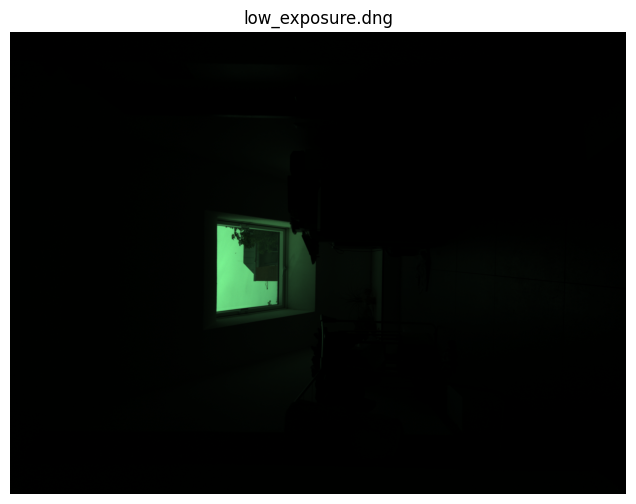

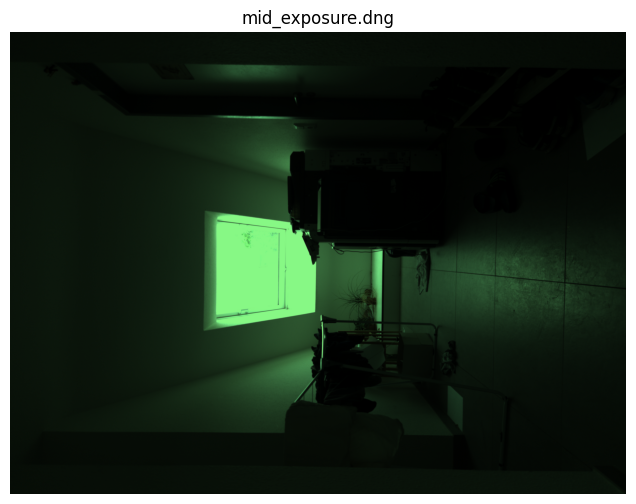

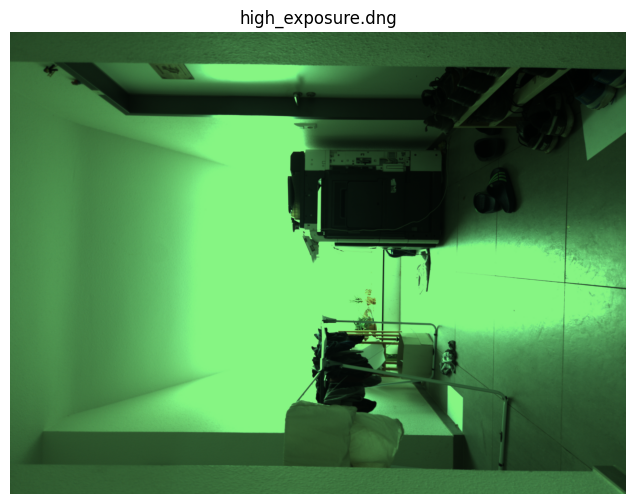

In [8]:

def normalize_for_display(img):
    """
    Normalize image array to uint8 RGB or grayscale for matplotlib display.
    """

    if img is None:
        return None

    img = np.asarray(img)
    img = np.squeeze(img)

    # If channel-first, move channels to the end.
    if img.ndim == 3 and img.shape[0] in [3, 4] and img.shape[-1] not in [3, 4]:
        img = np.moveaxis(img, 0, -1)

    # Remove alpha channel if present.
    if img.ndim == 3 and img.shape[-1] == 4:
        img = img[..., :3]

    img_float = img.astype(np.float32)

    min_val = np.nanmin(img_float)
    max_val = np.nanmax(img_float)

    if max_val > min_val:
        img_float = (img_float - min_val) / (max_val - min_val)
    else:
        img_float = np.zeros_like(img_float)

    img_8bit = np.clip(img_float * 255, 0, 255).astype(np.uint8)

    return img_8bit


for name, img in tifffile_images.items():
    display_img = normalize_for_display(img)

    if display_img is None:
        print(f"Skipping {name}: no image data")
        continue

    plt.figure(figsize=(8, 6))

    if display_img.ndim == 2:
        plt.imshow(display_img, cmap="gray")
    else:
        plt.imshow(display_img)

    plt.title(name)
    plt.axis("off")
    plt.show()

## 1.5 Read Individual TIFF/DNG Pages

Some DNG files contain multiple internal pages. One page may be a small preview, while another page may contain the main image.

This cell attempts to read each page separately and display its basic information.

In [9]:
# Cell 9: Read individual pages

def read_individual_tiff_pages(path):
    path = Path(path)

    print(f"Reading pages from: {path.name}")

    try:
        import tifffile as tiff

        page_arrays = []

        with tiff.TiffFile(str(path)) as tif:
            for i, page in enumerate(tif.pages):
                print(f"Reading page {i}...")

                try:
                    arr = page.asarray()
                    arr = np.asarray(arr)

                    print("  success")
                    print("  shape:", arr.shape)
                    print("  dtype:", arr.dtype)
                    print("  min/max:", arr.min(), arr.max())

                    page_arrays.append((i, arr))

                except Exception as exc:
                    print("  failed")
                    print("  error:", type(exc).__name__, exc)

        return page_arrays

    except Exception as exc:
        print("Could not open with tifffile.")
        print("Error:", type(exc).__name__, exc)

    return []


all_page_arrays = {}

for path in dng_paths:
    pages = read_individual_tiff_pages(path)
    all_page_arrays[path.name] = pages
    print("-" * 60)

Reading pages from: low_exposure.dng
Reading page 0...
  success
  shape: (3060, 4080, 3)
  dtype: uint16
  min/max: 0 3373
------------------------------------------------------------
Reading pages from: mid_exposure.dng
Reading page 0...
  success
  shape: (3060, 4080, 3)
  dtype: uint16
  min/max: 0 4201
------------------------------------------------------------
Reading pages from: high_exposure.dng
Reading page 0...
  success
  shape: (3060, 4080, 3)
  dtype: uint16
  min/max: 0 4253
------------------------------------------------------------


# Cell 10: Display readable pages


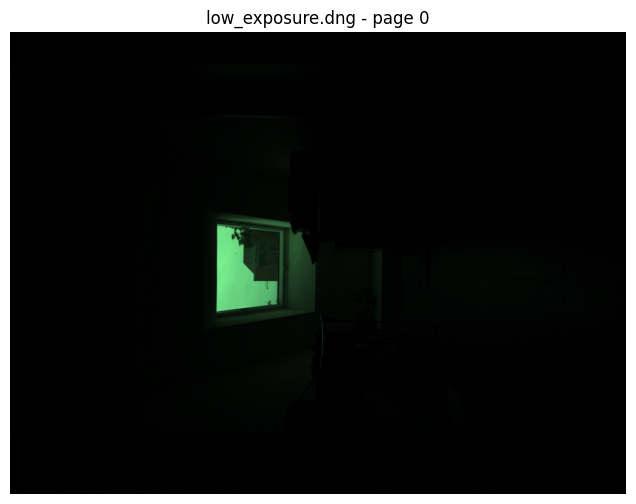

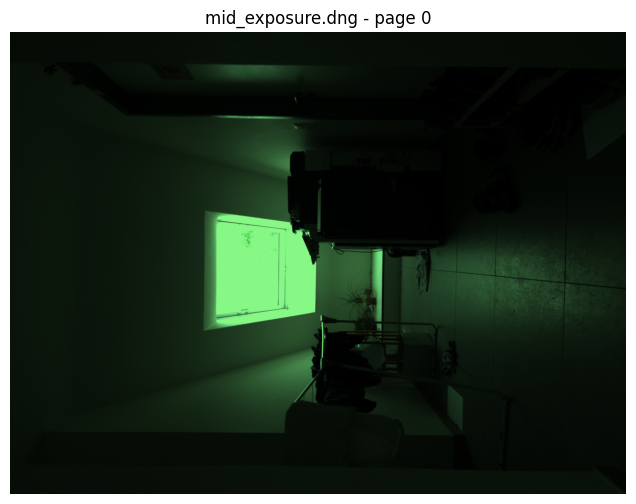

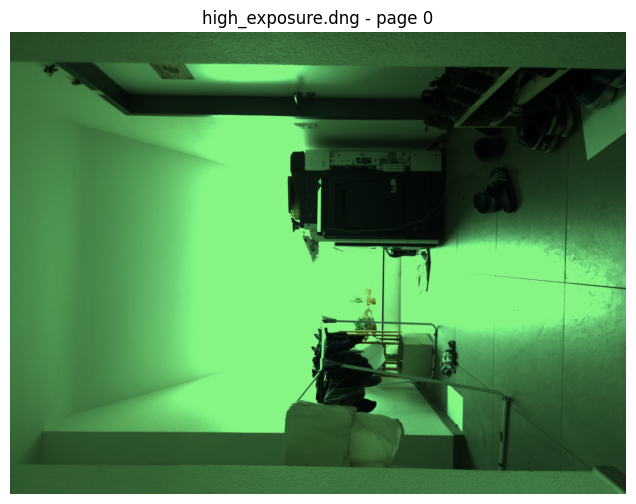

In [10]:

for filename, pages in all_page_arrays.items():
    for page_index, arr in pages:
        display_img = normalize_for_display(arr)

        if display_img is None:
            continue

        plt.figure(figsize=(8, 6))

        if display_img.ndim == 2:
            plt.imshow(display_img, cmap="gray")
        else:
            plt.imshow(display_img)

        plt.title(f"{filename} - page {page_index}")
        plt.axis("off")
        plt.show()

## 1.6 Diagnostic Summary

After running the cells above, use the table below to decide how the rest of the notebook should load the images.

| Result | Meaning | Next Step |
|---|---|---|
| `rawpy` succeeds | Conventional RAW/DNG | Use `rawpy` loader, then OpenCV |
| `cv2.imread` succeeds | OpenCV-readable image | Use OpenCV loader directly |
| `tifffile` succeeds and returns `(H, W, 3)` | RGB-like Linear DNG/TIFF | Use `tifffile` loader, then OpenCV |
| `tifffile` returns `(H, W)` | Single-channel Linear DNG or CFA-like data | May need grayscale handling or demosaicing |
| all fail | Unsupported or unusual DNG | Export to 16-bit TIFF using Lightroom/Adobe/Samsung tools |

For Samsung Expert RAW files, it is common that `rawpy`, OpenCV, and Darktable may not treat the files like conventional RAW images. In that case, `tifffile` or external export to 16-bit TIFF is often the most practical path.

# Cell 11: Simple automatic recommendation


In [11]:

def make_loading_recommendation():
    print("Loading recommendation:")
    print()

    any_tifffile_success = False
    any_opencv_success = False

    for path in dng_paths:
        img_cv = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
        if img_cv is not None:
            any_opencv_success = True

    try:
        import tifffile as tiff

        for path in dng_paths:
            try:
                img = tiff.imread(str(path))
                if img is not None:
                    any_tifffile_success = True
            except Exception:
                pass

    except ImportError:
        pass

    if any_opencv_success:
        print("At least one file can be read by OpenCV.")
        print("Use OpenCV-based loading functions.")

    elif any_tifffile_success:
        print("OpenCV could not read the files, but tifffile could.")
        print("Use tifffile-based loading functions and then process with OpenCV.")

    else:
        print("Neither OpenCV nor tifffile could read the files.")
        print("Export the DNG files to 16-bit TIFF using Lightroom, Adobe Camera Raw, Samsung Gallery, or another compatible converter.")


make_loading_recommendation()

Loading recommendation:



[ WARN:0@17.076] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 37398 (0x9216) encountered
[ WARN:0@17.076] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 50964 (0xc714) encountered
[ WARN:0@17.076] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 50965 (0xc715) encountered
[ WARN:0@17.076] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 51009 (0xc741) encountered
[ WARN:0@17.076] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 51041 (0xc761) encountered
[ WARN:0@17.076] global grfmt_tiff.cpp:804 readData OpenCV TIFF: TIFFRGBAImageOK: Sorry, can not handle images with 12-bit samples
[ WARN:0@17.088] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 37398 (0x9216) encountered
[ WARN:0@17.088] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 50964 (0xc714) encoun

OpenCV could not read the files, but tifffile could.
Use tifffile-based loading functions and then process with OpenCV.


In [12]:
def render_for_display(
    img,
    black_percentile=0.1,
    white_percentile=99.8,
    gamma=1/2.2,
    apply_gray_world_wb=True
):
    """
    Approximate display rendering for Linear DNG / camera-space image arrays.

    This is for visualization only.
    It is not a complete RAW development pipeline.
    """

    if img is None:
        return None

    img = np.asarray(img)
    img = np.squeeze(img)

    # If channel-first, move channels to the end.
    if img.ndim == 3 and img.shape[0] in [3, 4] and img.shape[-1] not in [3, 4]:
        img = np.moveaxis(img, 0, -1)

    # Remove alpha channel if present.
    if img.ndim == 3 and img.shape[-1] == 4:
        img = img[..., :3]

    # If single-channel, make 3-channel for display.
    if img.ndim == 2:
        img = np.stack([img, img, img], axis=-1)

    img_float = img.astype(np.float32)

    # Robust normalization instead of min/max.
    # Min/max is usually bad because a few hot pixels or saturated pixels dominate the scale.
    black = np.percentile(img_float, black_percentile)
    white = np.percentile(img_float, white_percentile)

    img_float = (img_float - black) / max(white - black, 1e-8)
    img_float = np.clip(img_float, 0.0, 1.0)

    # Approximate white balance using gray-world assumption.
    if apply_gray_world_wb and img_float.ndim == 3 and img_float.shape[-1] == 3:
        channel_means = img_float.reshape(-1, 3).mean(axis=0)
        gray_mean = channel_means.mean()

        gains = gray_mean / np.maximum(channel_means, 1e-8)
        img_float = img_float * gains.reshape(1, 1, 3)
        img_float = np.clip(img_float, 0.0, 1.0)

    # Gamma correction for normal display.
    img_float = np.power(img_float, gamma)
    img_float = np.clip(img_float, 0.0, 1.0)

    return (img_float * 255).astype(np.uint8)

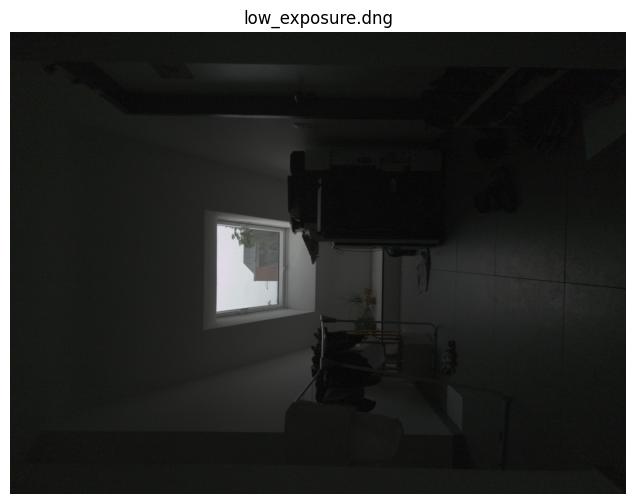

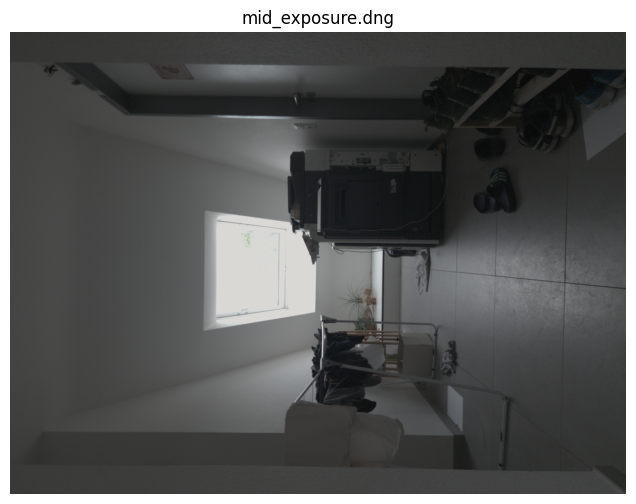

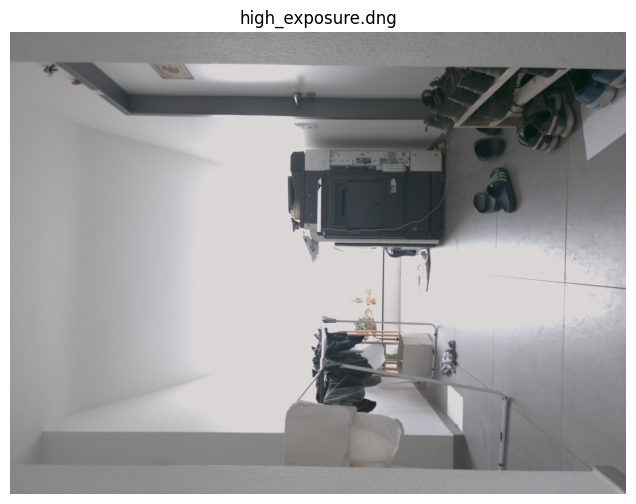

In [13]:
for name, img in tifffile_images.items():
    display_img = render_for_display(img)

    if display_img is None:
        print(f"Skipping {name}: no image data")
        continue

    plt.figure(figsize=(8, 6))
    plt.imshow(display_img)
    plt.title(name)
    plt.axis("off")
    plt.show()